1. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

시드 고정

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

2. 데이터 불러오기

In [3]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print("데이터 형태:", df.shape)

데이터 형태: (284807, 31)


3. 입력/출력 분리 및 스케일링

In [4]:
# 입력 / 출력 분리
X = df.drop(columns=['Class'])
y = df['Class']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X: 입력 특성 (30개)
y: 출력 라벨 (사기 여부)

train_test_split: 데이터를 8:2 비율로 나누고, stratify=y로 클래스 비율 유지

StandardScaler: 평균 0, 표준편차 1로 정규화 → 신경망 학습 속도와 안정성 향상

4. 클래스 가중치 계산

In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train   #y_train 안에서 각 클래스의 비율을 판단
)
#compute_class_weight 함수의 numpy 형태의 반환을 딕셔너리 형태로 변환
#딕셔너리로 변환하여 keras fit() 함수에 바로 넣을 수 있게 하기 위함
class_weights = {0: class_weights[0], 1: class_weights[1]}
print("클래스 가중치:", class_weights)

클래스 가중치: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


compute_class_weight 함수를 사용해 각 클래스의 빈도에 따라 자동으로 역비율 가중치를 계산 (즉, 빈도가 적을 수록 가중치가 커짐)



5. Self-Supervised Pretraining (AutoEncoder)

In [6]:
input_dim = X_train_scaled.shape[1] #X_train_scaled 데이터의 차원수 (30개)

# AutoEncoder 정의
input_layer = Input(shape=(input_dim,))                 #30차원
encoded = Dense(64, activation='relu')(input_layer)     #64차원
encoded = Dense(32, activation='relu')(encoded)         #32차원
decoded = Dense(64, activation='relu')(encoded)         #64차원
output_layer = Dense(input_dim, activation='linear')(decoded)   #30차원으로 복원

# 인코더+디코더 전체를 하나의 모델로 묶기 (즉, “입력 → 복원 출력” 전체 파이프라인을 하나의 네트워크로 정의)
autoencoder = Model(inputs=input_layer, outputs=output_layer)
# 모델 컴파일
autoencoder.compile(optimizer='adam', loss='mse')

print("\n===== [1단계] AutoEncoder 자기지도 사전학습 시작 =====")
# early stopping 기법으로 학습이 과적합 되기 전에 정지 (검증 손실 모니터링, 3 epoch 동안 개선 없으면 중단, 가장 성능 좋았던 시점의 가중치로 복원)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_ae = autoencoder.fit(
    #입력과 정답이 동일 (스스로 학습하는 구조)
    X_train_scaled, X_train_scaled,
    epochs=30,
    batch_size=512,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

# AutoEncoder의 입력부터, 인코더의 마지막 출력층(encoded)까지만 이어진 부분으로 새 모델 생성 (32차원 벡터를 반환)
encoder = Model(inputs=autoencoder.input, outputs=encoded)

X_train_encoded = encoder.predict(X_train_scaled)   #새로 만든 encoder 모델을 이용해 훈련데이터를 32차원으로 인코딩
X_test_encoded = encoder.predict(X_test_scaled)     #새로 만든 encoder 모델을 이용해 테스트데이터를 32차원으로 인코딩


===== [1단계] AutoEncoder 자기지도 사전학습 시작 =====
Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4057 - val_loss: 0.0855
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0483 - val_loss: 0.0311
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0219 - val_loss: 0.0172
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0118 - val_loss: 0.0102
Epoch 5/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 6/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 7/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 8/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 9/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - val_loss: 9.5641e-04
Epoch 10/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - val_loss: 8.9847e-04
Epoch 11/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.4887e-04 - val_loss: 7.3

인코딩된 데이터는 분류기(Classifier) 를 학습할 때 입력으로 사용 (즉, 다음 단계의 "지도학습 Fine-tuning”에서 사용)

6. Fine-tuning 분류기 정의

In [7]:
def build_classifier(input_dim):        # 바로 직전에 만든 32차원 잠재벡터를 입력으로 들어감
    model = Sequential([
        Input(shape=(input_dim,)),      # 32차원
        Dense(64, activation='relu'),   # 뉴런 64개 -
        BatchNormalization(),           # 각 배치별로 평균, 표준편차를 정규화 -> 학습 안정화
        Dropout(0.3),                   # dropout 으로 30프로 뉴런을 무작위로 꺼서 과적합 방지
        Dense(32, activation='relu'),   # 뉴런 32개로 줄임 -> 특징 압축
        Dense(1, activation='sigmoid')  # 1개의 출력(시그모이드 함수 -> 확률값 0~1) (2진 분류용)
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC()])
    return model

7. Fine-tuning 실험 (라벨 비율별, 무작위 샘플링)

In [8]:
ratios = [1.0, 0.5, 0.1]
results = []

for ratio in ratios:
    print(f"\n============================")
    print(f"Label Ratio = {int(ratio*100)}% (Fine-tuning)")
    print(f"============================")

    n_samples = int(len(X_train_encoded) * ratio)    # 인코딩된 전체 학습 데이터 개수 중 특정 비율 만큼만 샘플로 사용
    idx = np.random.choice(len(X_train_encoded), size=n_samples, replace=False)  # 무작위로 n_samples개 추출해서 랜덤 idx 배열을 생성

    X_sub = X_train_encoded[idx]    # 훈련 데이터셋의 무작위 인덱스로 선별한 배열
    y_sub = y_train.iloc[idx]       # 정답 라벨의 무작위 인덱스로 선별한 배열

    # 입력 차원에 맞는 분류기(Classifier) 모델을 새로 생성
    classifier = build_classifier(X_sub.shape[1])
    # early stopping 설정
    early_stop_cls = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # 모델 학습
    history_cls = classifier.fit(
        X_sub, y_sub,
        epochs=30,
        batch_size=512,
        validation_split=0.2,
        verbose=1,
        class_weight=class_weights,
        callbacks=[early_stop_cls]
    )

    # 평가
    y_pred = (classifier.predict(X_test_encoded) > 0.5).astype(int)
    auc = roc_auc_score(y_test, y_pred)  # AUC (Area Under the ROC Curve) 점수를 계산
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary', zero_division=0
    )

    print(f"Ratio {int(ratio*100)}% → AUC: {auc:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    results.append({
        "Ratio": ratio,
        "AUC": auc,
        "Recall": recall,
        "F1": f1
    })



Label Ratio = 100% (Fine-tuning)
Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9041 - auc: 0.9471 - loss: 0.2731 - val_accuracy: 0.9744 - val_auc: 0.9810 - val_loss: 0.1504
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9632 - auc: 0.9748 - loss: 0.1776 - val_accuracy: 0.9842 - val_auc: 0.9833 - val_loss: 0.0732
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9641 - auc: 0.9809 - loss: 0.1593 - val_accuracy: 0.9847 - val_auc: 0.9876 - val_loss: 0.0746
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9685 - auc: 0.9827 - loss: 0.1520 - val_accuracy: 0.9868 - val_auc: 0.9866 - val_loss: 0.0653
Epoch 5/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9605 - auc: 0.9802 - loss: 0.1645 - val_accuracy: 0.9723 - val_auc: 0.9873 - val_loss: 0.1080
Epoch 6/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9643 - auc: 0.9846 - loss: 0.1478 - val_accuracy: 0.9870 - val_auc: 0.9811 - val_loss: 0.0797
Epoch 

AUC : "모델이 실제 사기(1)와 정상(0)을 얼마나 잘 구별했는가" 평가

recall : “전체 사기 중 모델이 실제로 잡아낸 비율”

F1-score : “Precision(정밀도)”와 “Recall(재현율)”의 균형을 평가 (한 쪽만 높으면 평가 척도 하락)

8. 결과 시각화



실험 결과 요약:
   Ratio       AUC    Recall        F1
0    1.0  0.937107  0.887755  0.182199
1    0.5  0.930227  0.867347  0.295652
2    0.1  0.891380  0.785714  0.448980


C:\Users\ST-USER\PycharmProjects\PythonProject3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


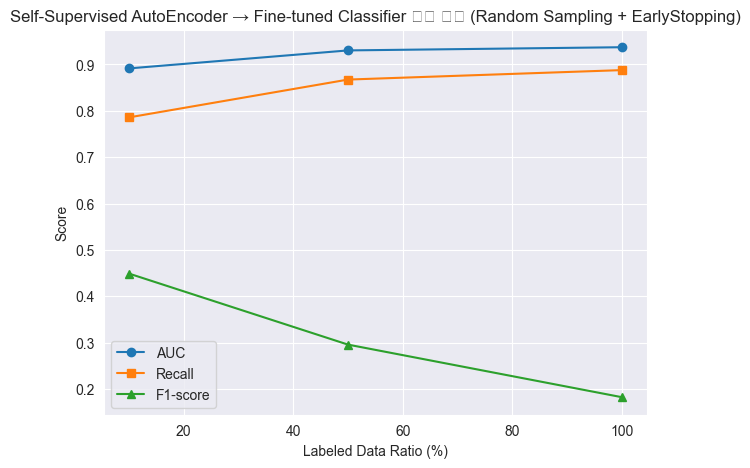

In [9]:
results_df = pd.DataFrame(results)
print("\n\n실험 결과 요약:")
print(results_df)

plt.figure(figsize=(7,5))
plt.plot(results_df["Ratio"]*100, results_df["AUC"], marker='o', label='AUC')
plt.plot(results_df["Ratio"]*100, results_df["Recall"], marker='s', label='Recall')
plt.plot(results_df["Ratio"]*100, results_df["F1"], marker='^', label='F1-score')
plt.title("Self-Supervised AutoEncoder → Fine-tuned Classifier 성능 비교 (Random Sampling + EarlyStopping)")
plt.xlabel("Labeled Data Ratio (%)")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()